# Mix Visualization (PCA + PaCMAP)

Visualize MAEST embeddings with mix-order trajectories for one or more mix subfolders.


In [2]:
from __future__ import annotations

import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pacmap
except ImportError:
    pacmap = None

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "music").exists() and (PROJECT_ROOT.parent / "music").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def to_project_relpath(path: str | Path) -> str:
    resolved = Path(path).expanduser().resolve()
    try:
        return str(resolved.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(resolved)


print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/josephdaher/Git Repositories/djprojectexploration


In [4]:
# Configure which mix folders to visualize.
# Initialized per request to music/ara and music/aries-mix.
MIX_SUBFOLDERS = [
    PROJECT_ROOT / "music" / "ara-mix",
    PROJECT_ROOT / "music" / "aries-mix",
]

# Optional aliases for renamed folders in this repo.
FOLDER_ALIASES = {
    "ara-mix": "ara",
}

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "maest_embeddings"
OUTPUT_DIR = EMBEDDINGS_DIR / "mix_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configured mix folders:")
for p in MIX_SUBFOLDERS:
    print(f"  - {to_project_relpath(p)}")
print(f"Embeddings dir: {to_project_relpath(EMBEDDINGS_DIR)}")
print(f"Output dir: {to_project_relpath(OUTPUT_DIR)}")


Configured mix folders:
  - music/ara-mix
  - music/aries-mix
Embeddings dir: data/maest_embeddings
Output dir: data/maest_embeddings/mix_visualization


In [5]:
def resolve_mix_folder(folder_path: Path) -> Path | None:
    folder_path = Path(folder_path)
    if not folder_path.is_absolute():
        folder_path = PROJECT_ROOT / folder_path

    if folder_path.exists():
        return folder_path

    alias = FOLDER_ALIASES.get(folder_path.name)
    if alias is not None:
        alt = folder_path.parent / alias
        if alt.exists():
            print(
                f"Folder not found: {to_project_relpath(folder_path)}; "
                f"using alias: {to_project_relpath(alt)}"
            )
            return alt

    print(f"Skipping missing folder: {to_project_relpath(folder_path)}")
    return None


def find_tracklist_csv(mix_dir: Path) -> Path:
    candidates = sorted(mix_dir.glob("*_tracks.csv"))
    if not candidates:
        raise FileNotFoundError(f"No *_tracks.csv found in {mix_dir}")
    return candidates[0]


resolved_mix_dirs: list[Path] = []
for folder in MIX_SUBFOLDERS:
    resolved = resolve_mix_folder(Path(folder))
    if resolved is not None:
        resolved_mix_dirs.append(resolved)

if not resolved_mix_dirs:
    raise RuntimeError("No valid mix folders found from MIX_SUBFOLDERS.")

mix_tracks: dict[str, list[dict]] = {}
mix_tracklist_csv: dict[str, Path] = {}
unique_mp3_names: set[str] = set()

for mix_dir in resolved_mix_dirs:
    mix_name = mix_dir.name
    tracklist_csv = find_tracklist_csv(mix_dir)

    rows: list[dict] = []
    with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
            mp3_name = (row.get("mp3_name") or "").strip().lower()
            title = (row.get("title") or "").strip()
            genre = (row.get("genre") or "").strip() or "Unknown"

            if not track_num_raw or not mp3_name:
                continue

            try:
                track_num = int(track_num_raw)
            except ValueError:
                continue

            rows.append(
                {
                    "mix_name": mix_name,
                    "track_num": track_num,
                    "mp3_name": mp3_name,
                    "title": title,
                    "genre": genre,
                }
            )
            unique_mp3_names.add(mp3_name)

    rows.sort(key=lambda x: x["track_num"])
    mix_tracks[mix_name] = rows
    mix_tracklist_csv[mix_name] = tracklist_csv

    print(f"Loaded mix: {mix_name}")
    print(f"  Tracklist: {to_project_relpath(tracklist_csv)}")
    print(f"  Tracks in CSV: {len(rows)}")

print(f"Total unique mp3 names across selected mixes: {len(unique_mp3_names)}")


Loaded mix: ara-mix
  Tracklist: music/ara-mix/ara_mix_tracks.csv
  Tracks in CSV: 23
Loaded mix: aries-mix
  Tracklist: music/aries-mix/aries_mix_tracks.csv
  Tracks in CSV: 25
Total unique mp3 names across selected mixes: 48


In [6]:
if not EMBEDDINGS_DIR.exists():
    raise FileNotFoundError(f"Embeddings directory not found: {EMBEDDINGS_DIR}")


def default_npz_name(tracklist_csv: Path) -> str:
    stem = tracklist_csv.stem
    if stem.endswith("_tracks"):
        return f"{stem}.npz"
    return f"{stem}_tracks.npz"


def normalize_filename_token(value: str) -> str:
    return Path(str(value).strip()).name.lower()


embedding_lookup: dict[str, np.ndarray] = {}
loaded_npz_files: list[Path] = []

for mix_name in sorted(mix_tracks.keys()):
    tracklist_csv = mix_tracklist_csv[mix_name]
    npz_file = EMBEDDINGS_DIR / default_npz_name(tracklist_csv)
    if not npz_file.exists():
        raise FileNotFoundError(
            f"MAEST NPZ not found for mix '{mix_name}': {npz_file}\n"
            f"Generate it with: uv run djprojectexploration-maest-playlist {to_project_relpath(tracklist_csv)}"
        )

    payload = np.load(npz_file, allow_pickle=False)
    if "embeddings" not in payload.files or "filenames" not in payload.files:
        raise KeyError(
            f"NPZ must contain `embeddings` and `filenames`: {npz_file}\n"
            f"Keys: {sorted(payload.files)}"
        )

    npz_embeddings = np.asarray(payload["embeddings"], dtype=np.float32)
    npz_filenames = [str(x) for x in payload["filenames"]]

    if npz_embeddings.ndim != 2 or npz_embeddings.shape[0] == 0:
        raise ValueError(f"Invalid embeddings matrix in NPZ: {npz_file} shape={npz_embeddings.shape}")
    if len(npz_filenames) != npz_embeddings.shape[0]:
        raise ValueError(
            f"`filenames` length must match embedding rows in NPZ: {npz_file} "
            f"({len(npz_filenames)} vs {npz_embeddings.shape[0]})"
        )

    for i, raw_name in enumerate(npz_filenames):
        token = normalize_filename_token(raw_name)
        vec = np.asarray(npz_embeddings[i], dtype=np.float32).reshape(-1)
        if vec.size == 0:
            continue
        if token in embedding_lookup:
            if embedding_lookup[token].shape != vec.shape:
                raise ValueError(
                    f"Conflicting embedding dims for '{token}' across NPZ files: "
                    f"{embedding_lookup[token].shape} vs {vec.shape}"
                )
            continue
        embedding_lookup[token] = vec

    loaded_npz_files.append(npz_file)

loaded_records: list[dict] = []
missing_embeddings: list[str] = []
for mp3_name in sorted(unique_mp3_names):
    token = normalize_filename_token(mp3_name)
    vec = embedding_lookup.get(token)
    if vec is None:
        missing_embeddings.append(mp3_name)
        continue
    loaded_records.append({"filename": token, "embedding": vec})

if len(loaded_records) < 2:
    raise RuntimeError("Need at least 2 valid embeddings to plot PCA/PaCMAP.")

filenames = [r["filename"] for r in loaded_records]
embeddings = np.vstack([r["embedding"] for r in loaded_records]).astype(np.float32)
filename_to_idx = {name.lower(): i for i, name in enumerate(filenames)}

mix_ordered_matches: dict[str, list[dict]] = {}
for mix_name, tracks in mix_tracks.items():
    matched = []
    for row in tracks:
        idx = filename_to_idx.get(normalize_filename_token(row["mp3_name"]))
        if idx is None:
            continue
        matched.append({**row, "idx": idx})
    matched.sort(key=lambda x: x["track_num"])
    mix_ordered_matches[mix_name] = matched

print(f"Loaded embeddings: {embeddings.shape}")
print(f"Loaded NPZ files: {len(loaded_npz_files)}")
for npz_file in loaded_npz_files:
    print(f"  - {to_project_relpath(npz_file)}")

print(f"Missing/invalid embeddings: {len(missing_embeddings)}")
for mix_name, matched in mix_ordered_matches.items():
    print(f"  Matched tracks for {mix_name}: {len(matched)}/{len(mix_tracks[mix_name])}")

if missing_embeddings:
    print("First 10 missing embedding mp3 names:")
    for name in missing_embeddings[:10]:
        print(f"  - {name}")



Loaded embeddings: (48, 768)
Missing/invalid embeddings: 0
  Matched tracks for ara-mix: 23/23
  Matched tracks for aries-mix: 25/25


In [7]:
def plot_mix_projection(
    coords: np.ndarray,
    title: str,
    xlabel: str,
    ylabel: str,
    output_path: Path,
) -> None:
    fig, ax = plt.subplots(figsize=(14, 10))

    # Base layer: all matched embedded tracks from selected mixes.
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=32,
        color="#c7c7c7",
        alpha=0.45,
        label="All embedded tracks",
        zorder=1,
    )

    all_matches = [item for items in mix_ordered_matches.values() for item in items]
    if not all_matches:
        raise RuntimeError("No mix-order track matches available for plotting.")

    # Color matched points by genre (global across selected mixes).
    genres = sorted({item["genre"] for item in all_matches}, key=lambda g: g.lower())
    cmap_genre = plt.get_cmap("tab20", max(1, len(genres)))
    genre_to_color = {genre: cmap_genre(i) for i, genre in enumerate(genres)}

    for genre in genres:
        genre_points = [item for item in all_matches if item["genre"] == genre]
        genre_idx = [item["idx"] for item in genre_points]
        genre_coords = coords[genre_idx]
        ax.scatter(
            genre_coords[:, 0],
            genre_coords[:, 1],
            s=90,
            color=genre_to_color[genre],
            edgecolor="black",
            linewidth=0.35,
            alpha=0.95,
            label=f"Genre: {genre}",
            zorder=3,
        )

    # Draw one mix-order path per selected mix folder.
    mix_names = sorted(mix_ordered_matches.keys())
    cmap_mix = plt.get_cmap("tab10", max(1, len(mix_names)))

    for i, mix_name in enumerate(mix_names):
        ordered_matches = mix_ordered_matches[mix_name]
        if not ordered_matches:
            continue

        order_idx = [item["idx"] for item in ordered_matches]
        path_coords = coords[order_idx]
        mix_color = cmap_mix(i)

        ax.plot(
            path_coords[:, 0],
            path_coords[:, 1],
            color=mix_color,
            linewidth=2.0,
            alpha=0.85,
            label=f"Mix order path: {mix_name}",
            zorder=2,
        )

        first = ordered_matches[0]
        last = ordered_matches[-1]
        ax.scatter(
            coords[first["idx"], 0],
            coords[first["idx"], 1],
            s=170,
            marker="*",
            color=mix_color,
            edgecolor="black",
            linewidth=0.8,
            zorder=5,
        )
        ax.scatter(
            coords[last["idx"], 0],
            coords[last["idx"], 1],
            s=120,
            marker="X",
            color=mix_color,
            edgecolor="black",
            linewidth=0.8,
            zorder=5,
        )

        ax.text(
            coords[first["idx"], 0],
            coords[first["idx"], 1],
            f"  START {mix_name} #{first['track_num']}",
            fontsize=8,
            weight="bold",
        )
        ax.text(
            coords[last["idx"], 0],
            coords[last["idx"], 1],
            f"  END {mix_name} #{last['track_num']}",
            fontsize=8,
            weight="bold",
        )

        for item in ordered_matches:
            label_title = item["title"] if item["title"] else Path(item["mp3_name"]).stem
            ax.text(
                coords[item["idx"], 0],
                coords[item["idx"], 1],
                f" [{mix_name}] #{item['track_num']} - {label_title}",
                fontsize=7,
                va="center",
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8)

    fig.tight_layout()
    fig.savefig(output_path, dpi=220)
    plt.show()

    print(f"Saved plot: {to_project_relpath(output_path)}")


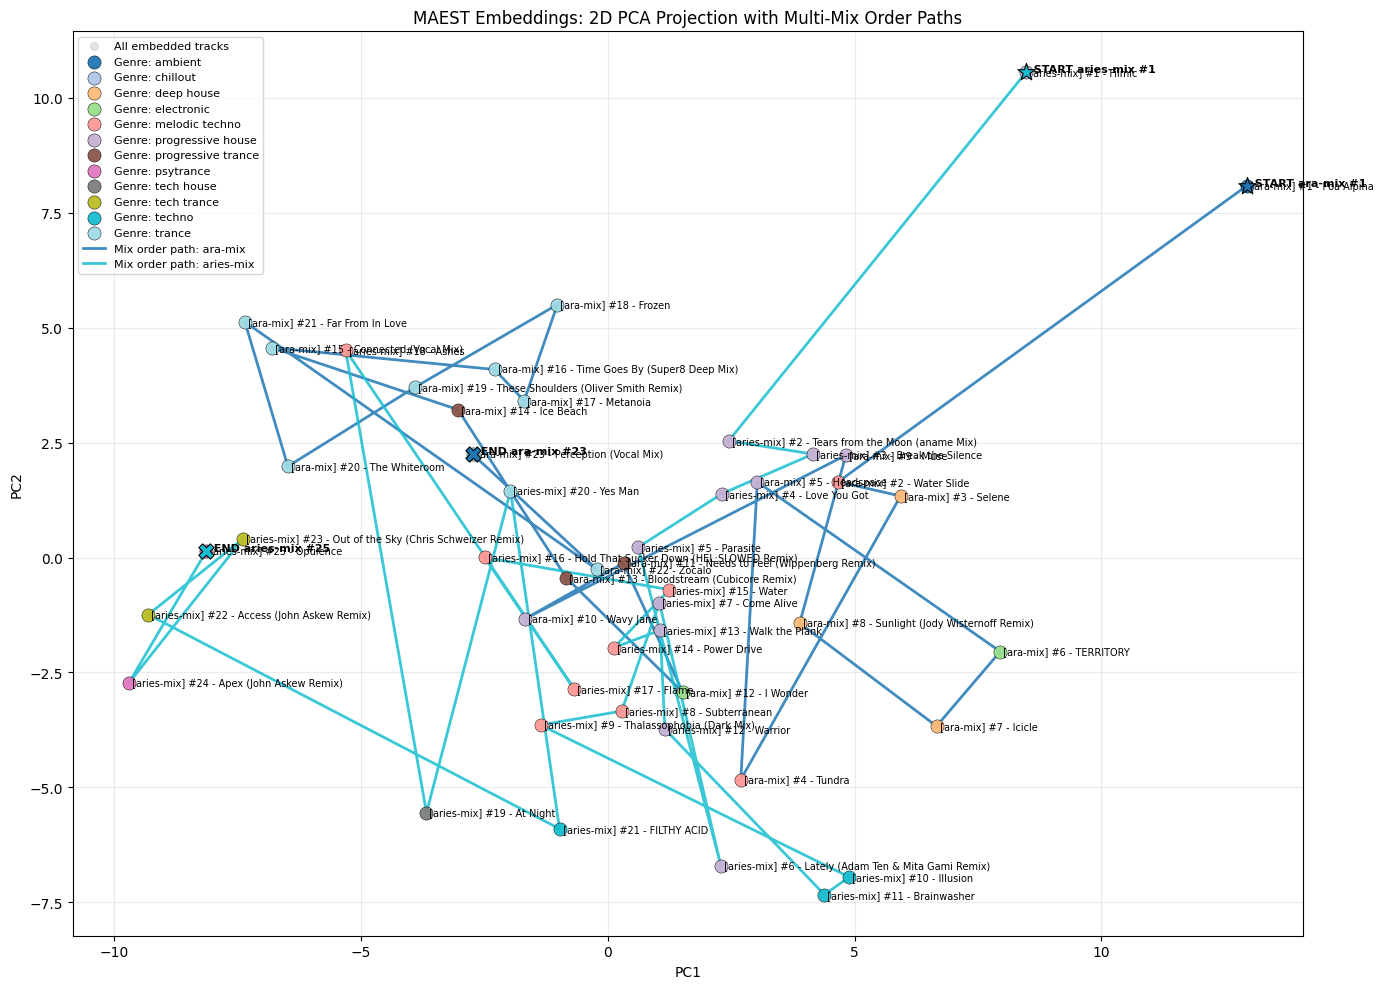

Saved plot: data/maest_embeddings/mix_visualization/mix_visualization_pca_plot.png


In [8]:
if embeddings.shape[0] < 2:
    raise ValueError("Need at least 2 tracks to build a 2D PCA projection.")

centered = embeddings - embeddings.mean(axis=0, keepdims=True)
_u, _s, vt = np.linalg.svd(centered, full_matrices=False)
coords_pca = centered @ vt[:2].T
if coords_pca.shape[1] < 2:
    coords_pca = np.pad(coords_pca, ((0, 0), (0, 2 - coords_pca.shape[1])), mode="constant")

plot_mix_projection(
    coords=coords_pca,
    title="MAEST Embeddings: 2D PCA Projection with Multi-Mix Order Paths",
    xlabel="PC1",
    ylabel="PC2",
    output_path=OUTPUT_DIR / "mix_visualization_pca_plot.png",
)


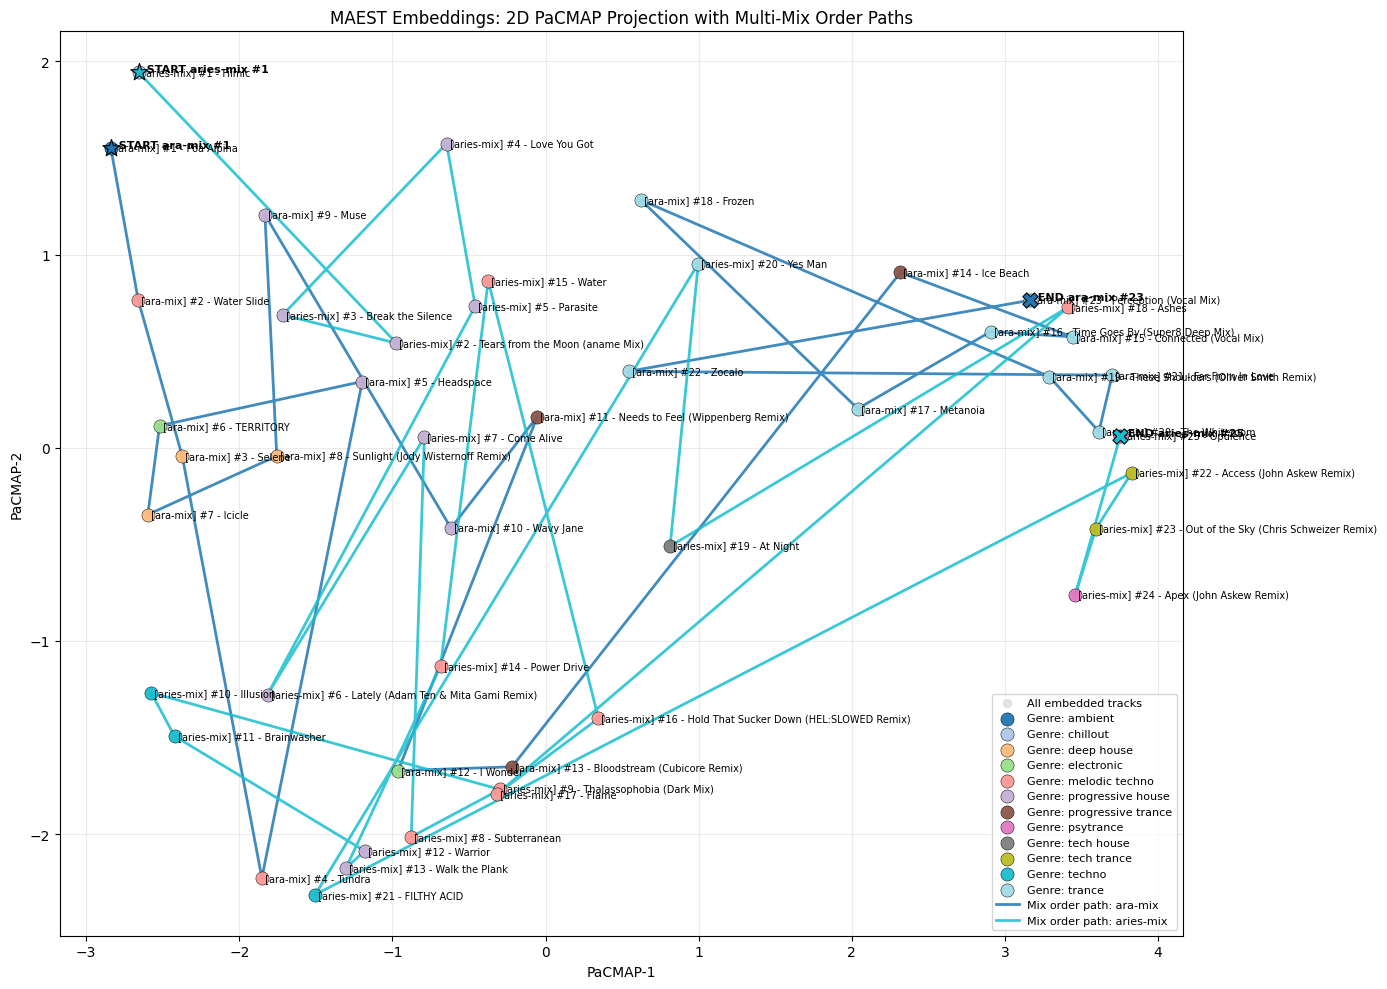

Saved plot: data/maest_embeddings/mix_visualization/mix_visualization_pacmap_plot.png


In [9]:
if pacmap is None:
    raise ImportError("PaCMAP is not installed in this environment. Install with: pip install pacmap")

if embeddings.shape[0] < 2:
    raise ValueError("Need at least 2 tracks to build a 2D PaCMAP projection.")

reducer = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=min(10, max(2, embeddings.shape[0] - 1)),
    MN_ratio=0.5,
    FP_ratio=1.5,
    random_state=7777,
)
coords_pacmap = reducer.fit_transform(embeddings.astype(np.float32))

plot_mix_projection(
    coords=coords_pacmap,
    title="MAEST Embeddings: 2D PaCMAP Projection with Multi-Mix Order Paths",
    xlabel="PaCMAP-1",
    ylabel="PaCMAP-2",
    output_path=OUTPUT_DIR / "mix_visualization_pacmap_plot.png",
)


## NPZ Embeddings + Genre CSV (No Order)

Use this section when you already have a single playlist embedding `.npz` file and a genre-tag CSV.

- No mix-order path is used here.
- Points are colored by genre from the CSV.
- Both PCA and PaCMAP projections are produced.


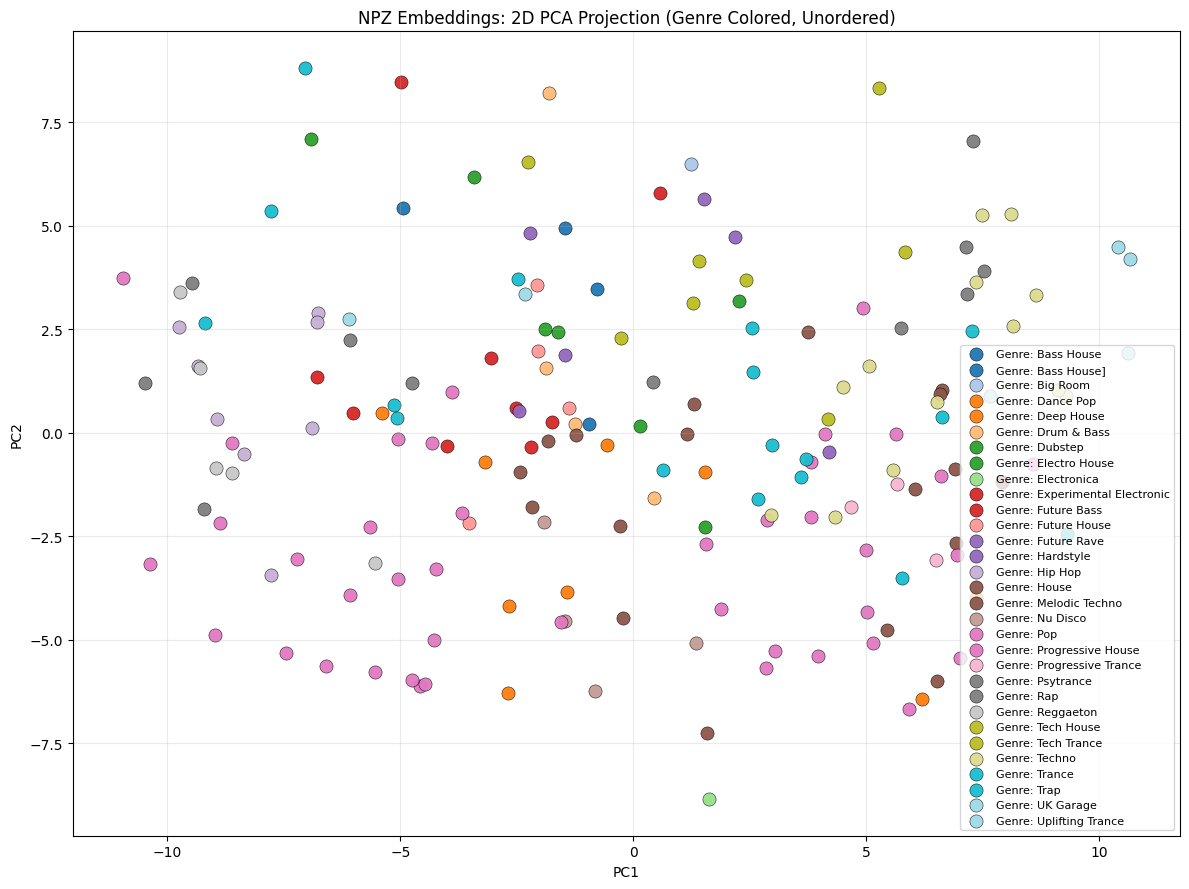

Saved plot: data/maest_embeddings/mix_visualization/npz_genre_visualization/npz_genre_pca_plot.png


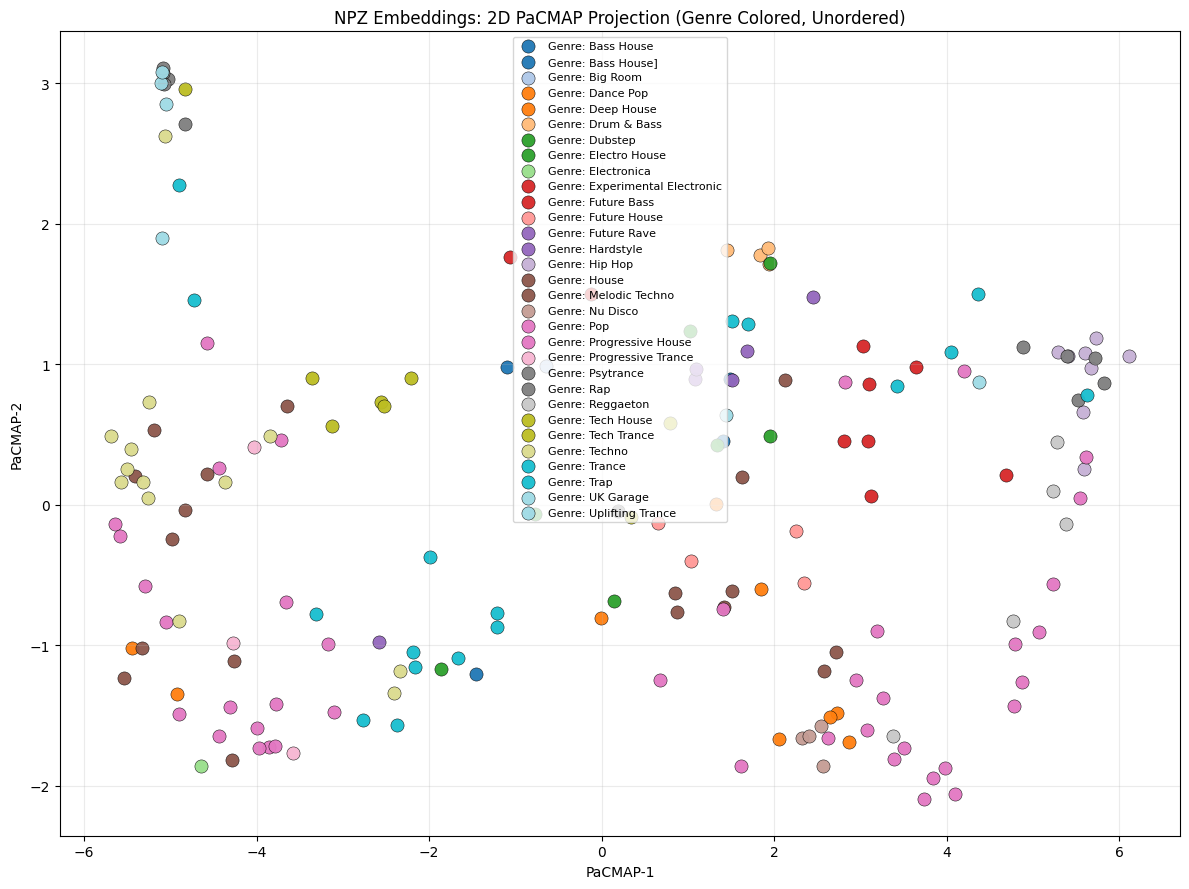

Saved plot: data/maest_embeddings/mix_visualization/npz_genre_visualization/npz_genre_pacmap_plot.png
NPZ embeddings shape: (179, 768)
Genre CSV rows mapped: 179/179
Genre counts:
  - Bass House: 3
  - Bass House]: 1
  - Big Room: 1
  - Dance Pop: 7
  - Deep House: 2
  - Drum & Bass: 4
  - Dubstep: 2
  - Electro House: 5
  - Electronica: 1
  - Experimental Electronic: 3
  - Future Bass: 6
  - Future House: 4
  - Future Rave: 1
  - Hardstyle: 5
  - Hip Hop: 8
  - House: 8
  - Melodic Techno: 10
  - Nu Disco: 4
  - Pop: 22
  - Progressive House: 19
  - Progressive Trance: 3
  - Psytrance: 6
  - Rap: 5
  - Reggaeton: 5
  - Tech House: 7
  - Tech Trance: 1
  - Techno: 13
  - Trance: 11
  - Trap: 6
  - UK Garage: 2
  - Uplifting Trance: 4


In [10]:
# Configure NPZ + CSV inputs for unordered genre-based visualization.
# Example NPZ: data/maest_embeddings/ara_mix_tracks.npz
# Example CSV: music/ara-mix/ara_mix_tracks.csv or Apple export CSV with filepath+genre
NPZ_EMBEDDINGS_FILE = PROJECT_ROOT / "data" / "maest_embeddings" / "dataset_tracks.npz"
GENRE_TAGS_CSV = PROJECT_ROOT / "data" / "exports" / "dataset_tracks.csv"

# Optional manual genre collapsing. Keys are matched case-insensitively against raw CSV genres.
GENRE_ALIAS_MAP: dict[str, str] = {
    'progressive trance': 'Trance',
    'uplifting trance': 'Trance',
    'psytrance': 'Trance',
    'tech trance': 'Trance',
    'progressive house': 'House',
    'deep house': 'House',
    'tech house': 'House',
    'future house': 'House',
}
# Keep only these final identities (set to None to keep everything after alias mapping).
GENRE_WHITELIST: set[str] | None = None
OTHER_GENRE_LABEL = 'Other'

def canonicalize_genre(raw_genre: str) -> str:
    genre = (raw_genre or '').strip() or 'Unknown'
    canonical = GENRE_ALIAS_MAP.get(genre.casefold(), genre)
    if GENRE_WHITELIST is None:
        return canonical
    allowed = {g.casefold() for g in GENRE_WHITELIST}
    return canonical if canonical.casefold() in allowed else OTHER_GENRE_LABEL
NPZ_OUTPUT_DIR = OUTPUT_DIR / "npz_genre_visualization"
NPZ_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not NPZ_EMBEDDINGS_FILE.exists():
    raise FileNotFoundError(f"NPZ embeddings file not found: {NPZ_EMBEDDINGS_FILE}")
if not GENRE_TAGS_CSV.exists():
    raise FileNotFoundError(f"Genre CSV file not found: {GENRE_TAGS_CSV}")

npz_payload = np.load(NPZ_EMBEDDINGS_FILE)
if "embeddings" not in npz_payload.files:
    raise KeyError("NPZ must contain an `embeddings` array.")
if "filenames" not in npz_payload.files:
    raise KeyError("NPZ must contain a `filenames` array for CSV matching.")

npz_embeddings = np.asarray(npz_payload["embeddings"], dtype=np.float32)
npz_filenames = [str(x) for x in npz_payload["filenames"]]

if npz_embeddings.ndim != 2 or npz_embeddings.shape[0] < 2:
    raise ValueError("Need a 2D embedding matrix with at least 2 tracks in the NPZ.")
if len(npz_filenames) != npz_embeddings.shape[0]:
    raise ValueError("`filenames` length must match number of embedding rows.")

def normalize_filename_token(value: str) -> str:
    return Path(str(value).strip()).name.lower()

def row_to_match_token(row: dict) -> str | None:
    candidates = [
        row.get("mp3_name"),
        row.get("filename"),
        row.get("filepath"),
        row.get("location"),
    ]
    for raw in candidates:
        text = (raw or "").strip()
        if text:
            return normalize_filename_token(text)
    return None

genre_lookup: dict[str, str] = {}
with GENRE_TAGS_CSV.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        token = row_to_match_token(row)
        if token is None:
            continue
        raw_genre = (row.get("genre") or "").strip() or "Unknown"
        genre_lookup[token] = canonicalize_genre(raw_genre)

assigned_genres: list[str] = []
for filename in npz_filenames:
    token = normalize_filename_token(filename)
    assigned_genres.append(canonicalize_genre(genre_lookup.get(token, "Unknown")))

def plot_projection_by_genre(
    coords: np.ndarray,
    genres: list[str],
    title: str,
    xlabel: str,
    ylabel: str,
    output_path: Path,
) -> None:
    fig, ax = plt.subplots(figsize=(12, 9))
    unique_genres = sorted(set(genres), key=lambda g: g.lower())
    cmap = plt.get_cmap("tab20", max(1, len(unique_genres)))
    color_map = {genre: cmap(i) for i, genre in enumerate(unique_genres)}

    for genre in unique_genres:
        idx = [i for i, g in enumerate(genres) if g == genre]
        pts = coords[idx]
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=90,
            color=color_map[genre],
            edgecolor="black",
            linewidth=0.35,
            alpha=0.95,
            label=f"Genre: {genre}",
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8)

    fig.tight_layout()
    fig.savefig(output_path, dpi=220)
    plt.show()
    print(f"Saved plot: {to_project_relpath(output_path)}")

# PCA
centered = npz_embeddings - npz_embeddings.mean(axis=0, keepdims=True)
_u, _s, vt = np.linalg.svd(centered, full_matrices=False)
coords_pca_npz = centered @ vt[:2].T
if coords_pca_npz.shape[1] < 2:
    coords_pca_npz = np.pad(coords_pca_npz, ((0, 0), (0, 2 - coords_pca_npz.shape[1])), mode="constant")

plot_projection_by_genre(
    coords=coords_pca_npz,
    genres=assigned_genres,
    title="NPZ Embeddings: 2D PCA Projection (Genre Colored, Unordered)",
    xlabel="PC1",
    ylabel="PC2",
    output_path=NPZ_OUTPUT_DIR / "npz_genre_pca_plot.png",
)

# PaCMAP
if pacmap is None:
    raise ImportError("PaCMAP is not installed in this environment. Install with: pip install pacmap")

reducer = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=min(10, max(2, npz_embeddings.shape[0] - 1)),
    MN_ratio=0.5,
    FP_ratio=1.5,
    random_state=7777,
)
coords_pacmap_npz = reducer.fit_transform(npz_embeddings.astype(np.float32))

plot_projection_by_genre(
    coords=coords_pacmap_npz,
    genres=assigned_genres,
    title="NPZ Embeddings: 2D PaCMAP Projection (Genre Colored, Unordered)",
    xlabel="PaCMAP-1",
    ylabel="PaCMAP-2",
    output_path=NPZ_OUTPUT_DIR / "npz_genre_pacmap_plot.png",
)

genre_counts = {g: assigned_genres.count(g) for g in sorted(set(assigned_genres), key=lambda x: x.lower())}
print(f"NPZ embeddings shape: {npz_embeddings.shape}")
print(f"Genre CSV rows mapped: {sum(1 for g in assigned_genres if g != "Unknown")}/{len(assigned_genres)}")
print("Genre counts:")
for genre, count in genre_counts.items():
    print(f"  - {genre}: {count}")


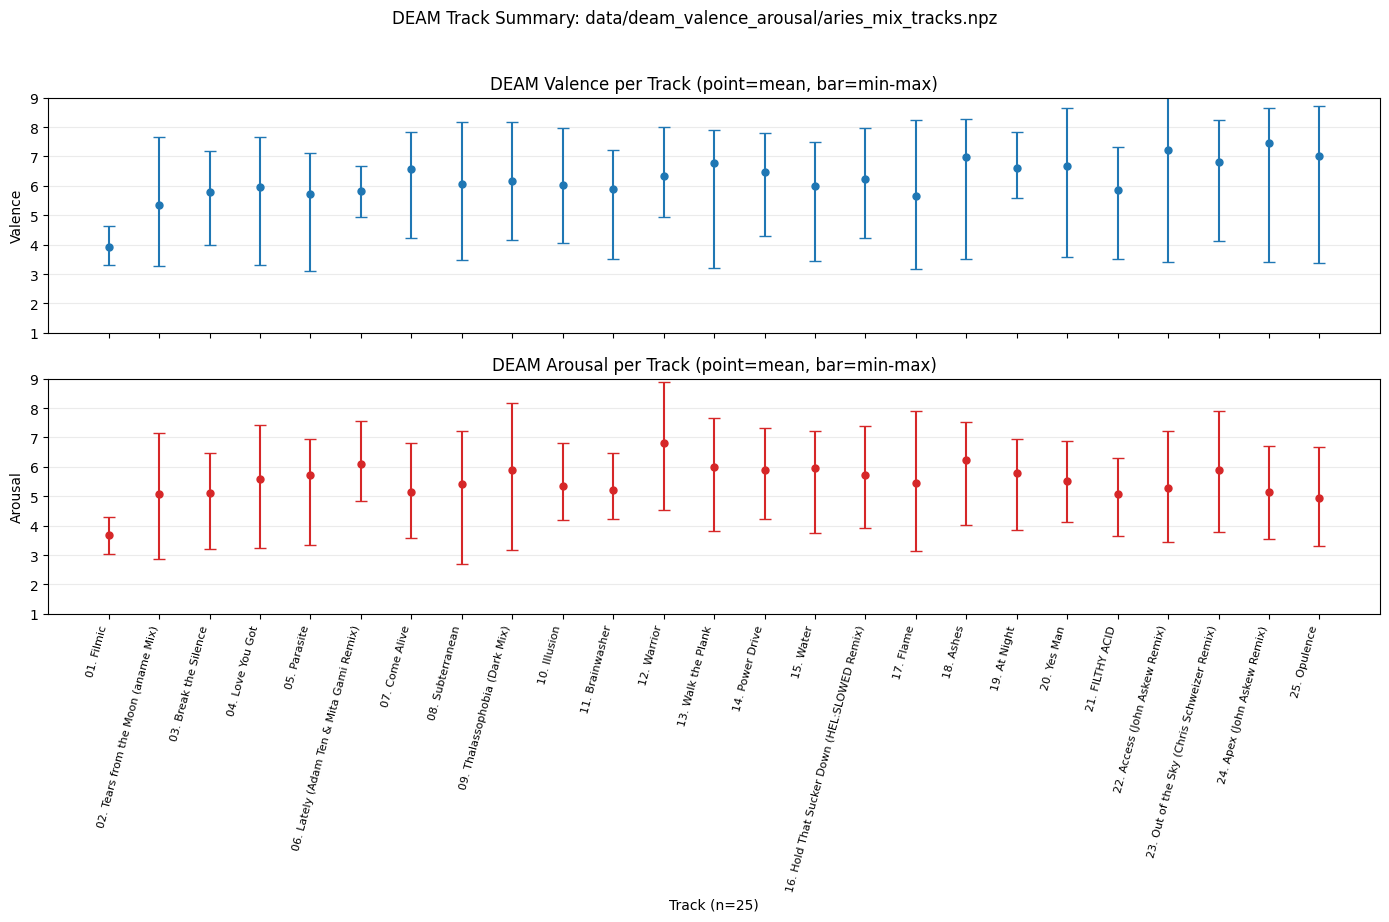

In [4]:
# DEAM valence/arousal per-track summary (mean point with min-max bars)
DEAM_NPZ_FILE = PROJECT_ROOT / "data" / "deam_valence_arousal" / "aries_mix_tracks.npz"

if not DEAM_NPZ_FILE.exists():
    raise FileNotFoundError(f"DEAM NPZ file not found: {DEAM_NPZ_FILE}")


deam = np.load(DEAM_NPZ_FILE, allow_pickle=False)
required = [
    "filenames",
    "titles",
    "track_numbers",
    "deam_valence_mean",
    "deam_valence_min",
    "deam_valence_max",
    "deam_arousal_mean",
    "deam_arousal_min",
    "deam_arousal_max",
]
missing = [k for k in required if k not in deam.files]
if missing:
    raise KeyError(f"Missing required DEAM NPZ keys: {missing}. Available: {sorted(deam.files)}")

n_tracks = int(np.asarray(deam["num_tracks"]).reshape(-1)[0]) if "num_tracks" in deam.files else len(deam["filenames"])
track_numbers = np.asarray(deam["track_numbers"], dtype=np.int32).reshape(-1)
titles = [str(v).strip() for v in deam["titles"]]
filenames = [str(v).strip() for v in deam["filenames"]]

val_mean = np.asarray(deam["deam_valence_mean"], dtype=np.float32).reshape(-1)
val_min = np.asarray(deam["deam_valence_min"], dtype=np.float32).reshape(-1)
val_max = np.asarray(deam["deam_valence_max"], dtype=np.float32).reshape(-1)
arr_mean = np.asarray(deam["deam_arousal_mean"], dtype=np.float32).reshape(-1)
arr_min = np.asarray(deam["deam_arousal_min"], dtype=np.float32).reshape(-1)
arr_max = np.asarray(deam["deam_arousal_max"], dtype=np.float32).reshape(-1)

lengths = [
    len(track_numbers),
    len(titles),
    len(filenames),
    len(val_mean), len(val_min), len(val_max),
    len(arr_mean), len(arr_min), len(arr_max),
]
if len(set(lengths)) != 1:
    raise ValueError(f"DEAM arrays have inconsistent lengths: {lengths}")

# Keep track order explicit and stable.
order = np.argsort(track_numbers, kind="stable")
track_numbers = track_numbers[order]
titles = [titles[i] for i in order]
filenames = [filenames[i] for i in order]
val_mean, val_min, val_max = val_mean[order], val_min[order], val_max[order]
arr_mean, arr_min, arr_max = arr_mean[order], arr_min[order], arr_max[order]

labels = [f"{int(num):02d}. {title or Path(name).stem}" for num, title, name in zip(track_numbers, titles, filenames, strict=False)]
x = np.arange(len(labels), dtype=np.int32)

val_yerr = np.vstack([val_mean - val_min, val_max - val_mean])
arr_yerr = np.vstack([arr_mean - arr_min, arr_max - arr_mean])

fig, axes = plt.subplots(2, 1, figsize=(max(14, len(labels) * 0.55), 9), sharex=True)

axes[0].errorbar(
    x,
    val_mean,
    yerr=val_yerr,
    fmt="o",
    ms=5,
    capsize=4,
    color="#1f77b4",
    ecolor="#1f77b4",
    elinewidth=1.5,
)
axes[0].set_title("DEAM Valence per Track (point=mean, bar=min-max)")
axes[0].set_ylabel("Valence")
axes[0].set_ylim(1.0, 9.0)
axes[0].grid(axis="y", alpha=0.25)

axes[1].errorbar(
    x,
    arr_mean,
    yerr=arr_yerr,
    fmt="o",
    ms=5,
    capsize=4,
    color="#d62728",
    ecolor="#d62728",
    elinewidth=1.5,
)
axes[1].set_title("DEAM Arousal per Track (point=mean, bar=min-max)")
axes[1].set_ylabel("Arousal")
axes[1].set_ylim(1.0, 9.0)
axes[1].grid(axis="y", alpha=0.25)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=75, ha="right", fontsize=8)
axes[1].set_xlabel(f"Track (n={n_tracks})")

fig.suptitle(f"DEAM Track Summary: {to_project_relpath(DEAM_NPZ_FILE)}", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()



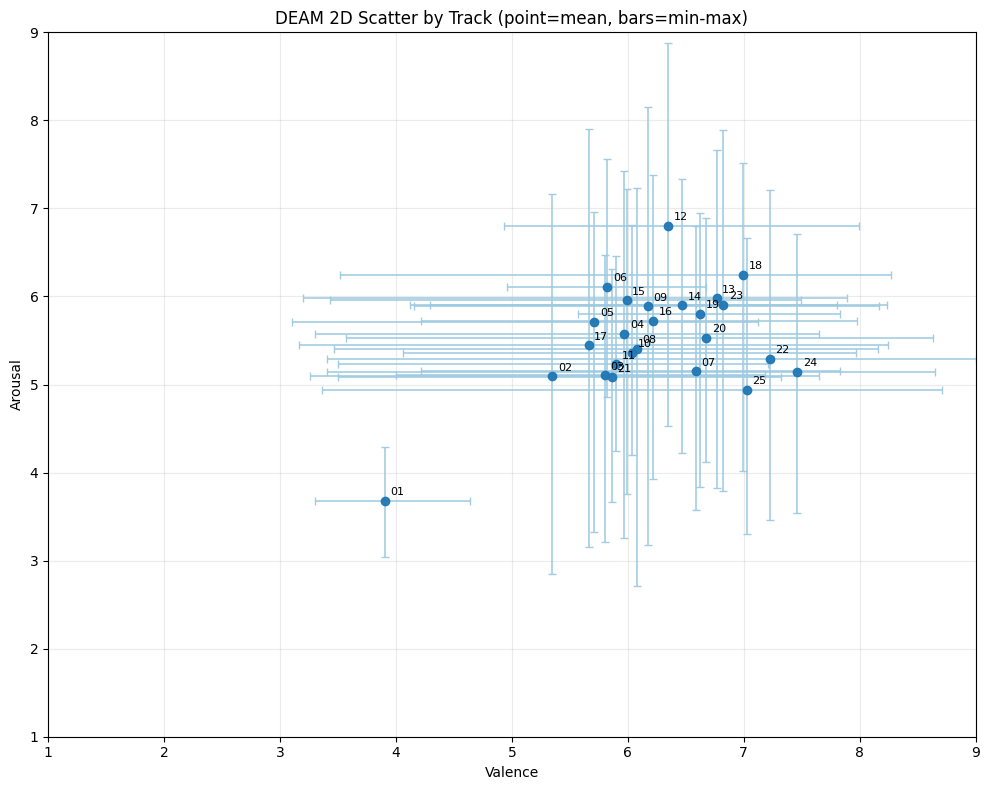

In [5]:
# DEAM 2D scatter: valence vs arousal (mean point with min-max bars)
DEAM_NPZ_FILE = PROJECT_ROOT / "data" / "deam_valence_arousal" / "aries_mix_tracks.npz"

if not DEAM_NPZ_FILE.exists():
    raise FileNotFoundError(f"DEAM NPZ file not found: {DEAM_NPZ_FILE}")

deam = np.load(DEAM_NPZ_FILE, allow_pickle=False)
required = [
    "track_numbers",
    "titles",
    "filenames",
    "deam_valence_mean",
    "deam_valence_min",
    "deam_valence_max",
    "deam_arousal_mean",
    "deam_arousal_min",
    "deam_arousal_max",
]
missing = [k for k in required if k not in deam.files]
if missing:
    raise KeyError(f"Missing required DEAM NPZ keys: {missing}. Available: {sorted(deam.files)}")

track_numbers = np.asarray(deam["track_numbers"], dtype=np.int32).reshape(-1)
titles = [str(v).strip() for v in deam["titles"]]
filenames = [str(v).strip() for v in deam["filenames"]]

val_mean = np.asarray(deam["deam_valence_mean"], dtype=np.float32).reshape(-1)
val_min = np.asarray(deam["deam_valence_min"], dtype=np.float32).reshape(-1)
val_max = np.asarray(deam["deam_valence_max"], dtype=np.float32).reshape(-1)
arr_mean = np.asarray(deam["deam_arousal_mean"], dtype=np.float32).reshape(-1)
arr_min = np.asarray(deam["deam_arousal_min"], dtype=np.float32).reshape(-1)
arr_max = np.asarray(deam["deam_arousal_max"], dtype=np.float32).reshape(-1)

lengths = [
    len(track_numbers),
    len(titles),
    len(filenames),
    len(val_mean), len(val_min), len(val_max),
    len(arr_mean), len(arr_min), len(arr_max),
]
if len(set(lengths)) != 1:
    raise ValueError(f"DEAM arrays have inconsistent lengths: {lengths}")

order = np.argsort(track_numbers, kind="stable")
track_numbers = track_numbers[order]
titles = [titles[i] for i in order]
filenames = [filenames[i] for i in order]
val_mean, val_min, val_max = val_mean[order], val_min[order], val_max[order]
arr_mean, arr_min, arr_max = arr_mean[order], arr_min[order], arr_max[order]

xerr = np.vstack([val_mean - val_min, val_max - val_mean])
yerr = np.vstack([arr_mean - arr_min, arr_max - arr_mean])

fig, ax = plt.subplots(figsize=(10, 8))
ax.errorbar(
    val_mean,
    arr_mean,
    xerr=xerr,
    yerr=yerr,
    fmt="o",
    color="#1f77b4",
    ecolor="#9ecae1",
    elinewidth=1.2,
    capsize=3,
    alpha=0.95,
)

for i, (x, y) in enumerate(zip(val_mean, arr_mean, strict=False)):
    label = f"{int(track_numbers[i]):02d}"
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8)

ax.set_xlim(1.0, 9.0)
ax.set_ylim(1.0, 9.0)
ax.set_xlabel("Valence")
ax.set_ylabel("Arousal")
ax.set_title("DEAM 2D Scatter by Track (point=mean, bars=min-max)")
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

